In [1]:
#create a dataset, for ex, we r taking daily electricity consumption of 20 houses


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

data=np.array([4.3, 5.1, 3.8, 4.5, 5.0, 4.2, 4.8, 5.3, 4.6, 4.9, 5.2, 4.7, 4.4, 5.0, 4.9, 5.1, 4.3, 4.6, 5.0, 4.8])



In [3]:
#step 1: claculate sample mean and variance

mean=np.mean(data)
variance=np.var(data, ddof=1) 
print("Sample Mean:", mean)
print("Sample Variance:", variance)

Sample Mean: 4.725
Sample Variance: 0.14828947368421055


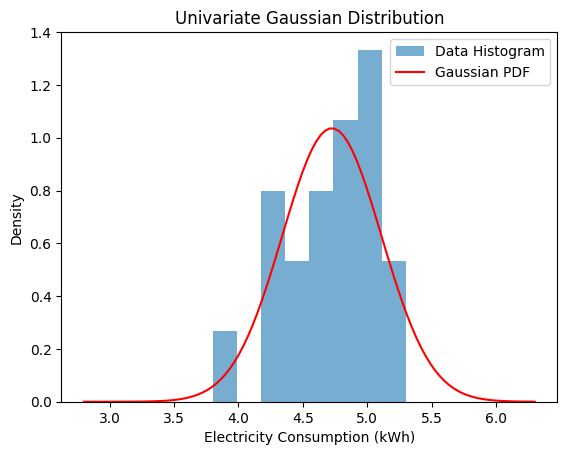

In [ ]:
x=np.linspace(min(data)-1, max(data)+1, 100)
pdf=norm.pdf(x, mean, np.sqrt(variance))
plt.hist(data, bins=8, density=True, alpha=0.6, label="Data Histogram")
plt.plot(x, pdf, 'r', label="Gaussian PDF")
plt.title("Univariate Gaussian Distribution")
plt.xlabel("Electricity Consumption (kWh)")
plt.ylabel("Density")
plt.legend()
plt.show()

Mean Vector:
 [4.94807674 2.00669138]
Covariance Matrix:
 [[ 0.20619247 -0.01772313]
 [-0.01772313  0.0818536 ]]


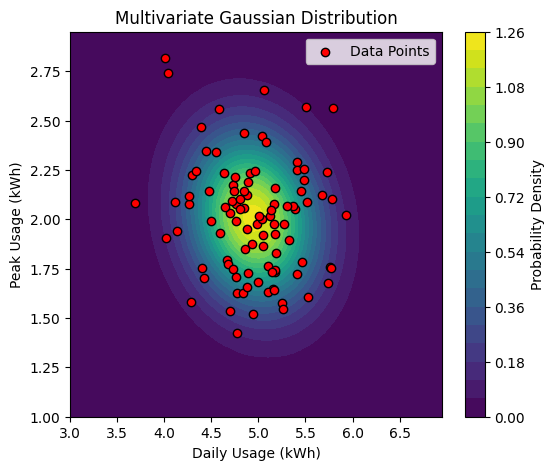

In [ ]:
#understand covariance and elliptical distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
 
np.random.seed(42)
 
#Generate data
daily=np.random.normal(5, 0.5, 100)
peak=np.random.normal(2, 0.3, 100)
 
X=np.column_stack((daily, peak))
 
#Estimate parameters
mean_vector=np.mean(X, axis=0)
cov_matrix=np.cov(X.T)
 
print("Mean Vector:\n", mean_vector)
print("Covariance Matrix:\n", cov_matrix)
 
#Create Gaussian model
rv= multivariate_normal(mean_vector, cov_matrix)
 
#Create grid
x, y= np.mgrid[3:7:0.05, 1:3:0.05]
pos= np.dstack((x, y))
 
#Plot contour
plt.figure(figsize=(6, 5))
plt.contourf(x, y, rv.pdf(pos), levels=20, cmap='viridis')
plt.colorbar(label='Probability Density')
 
#Plot data
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolor='k', label='Data Points')
 
plt.title("Multivariate Gaussian Distribution")
plt.xlabel("Daily Usage (kWh)")
plt.ylabel("Peak Usage (kWh)")
plt.legend()
plt.show()
 
 

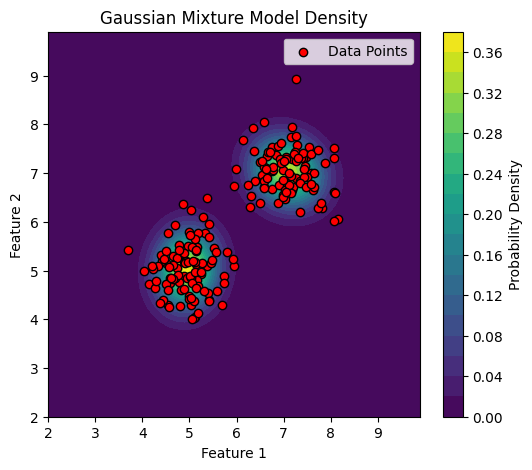

In [12]:
#plot gaussian mixture model density

from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt
# Generate synthetic data
np.random.seed(42)
data1 = np.random.normal(5, 0.5, (100, 2))
data2 = np.random.normal(7, 0.5, (100, 2
))
data = np.vstack((data1, data2))
# Fit GMM
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(data)
# Create grid for plotting
x, y = np.mgrid[2:10:0.1, 2:10:0.1]
pos = np.dstack((x, y))
# Compute GMM density
pdf = np.exp(gmm.score_samples(pos.reshape(-1, 2))).reshape(x.shape)
# Plot contour
plt.figure(figsize=(6, 5))
plt.contourf(x, y, pdf, levels=20, cmap='viridis')
plt.colorbar(label='Probability Density')
# Plot data
plt.scatter(data[:, 0], data[:, 1], c='red', edgecolor='k', label='Data Points')
plt.title("Gaussian Mixture Model Density")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2") 
plt.legend()
plt.show()